In [1]:
### Imports

import numpy as np
import pandas as pd

from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import BettiCurve
from gtda.plotting import plot_point_cloud, plot_diagram, plot_betti_curves

from gtda.time_series import SingleTakensEmbedding

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

from gen_data import make_time_series
from barcode import plot_betti_barcode

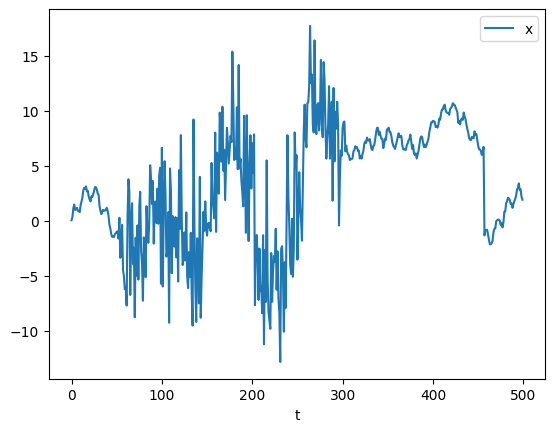

In [11]:
df = make_time_series(n=500, anomaly_strength=2, folding=False)
plt.figure()
plt.plot(df["t"], df["x"], label="x")
#plt.plot(df["t"], df["x2"], label="x2")
#plt.plot(df["t"], df["x3"], label="x3")
plt.xlabel("t")
plt.legend()
plt.show()

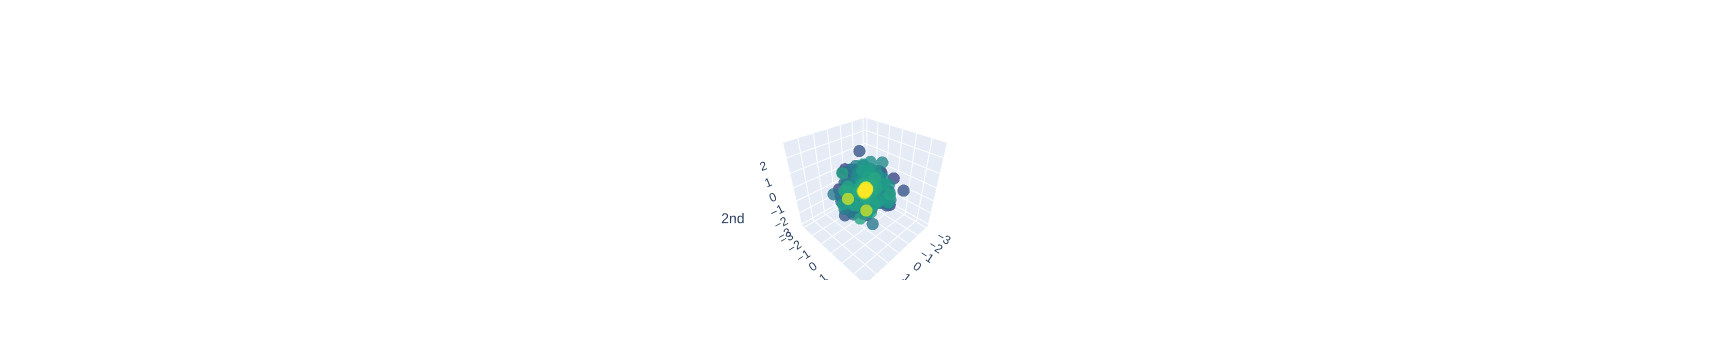

In [3]:
# Generate point cloud
x = StandardScaler().fit_transform(df[["x"]])

TE = SingleTakensEmbedding(time_delay=1, dimension=3)
point_cloud = TE.fit_transform(x)

plot_point_cloud(point_cloud)

CPU times: user 34.2 ms, sys: 6.57 ms, total: 40.8 ms
Wall time: 6.5 s


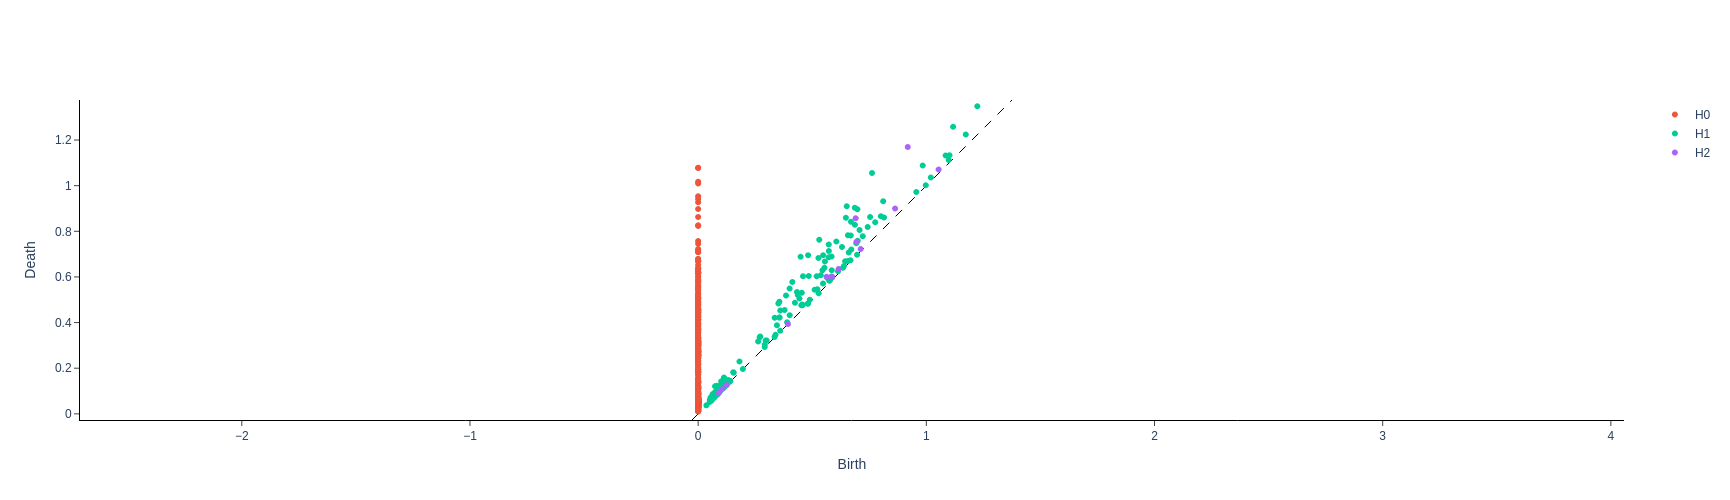

In [4]:
# track connected components, loops, and voids
homology_dimensions = [0, 1, 2]

persistence = VietorisRipsPersistence(metric="euclidean", homology_dimensions=homology_dimensions, n_jobs=6)

# add batch dimension
X = point_cloud.reshape(1, *point_cloud.shape)
%time diagrams = persistence.fit_transform(X)
plot_diagram(diagrams[0])

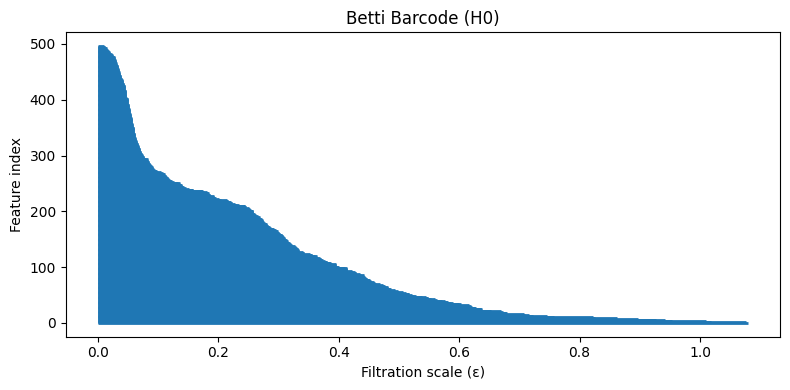

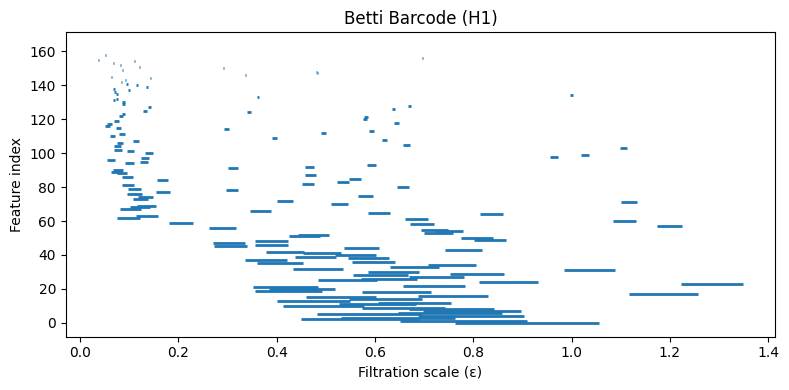

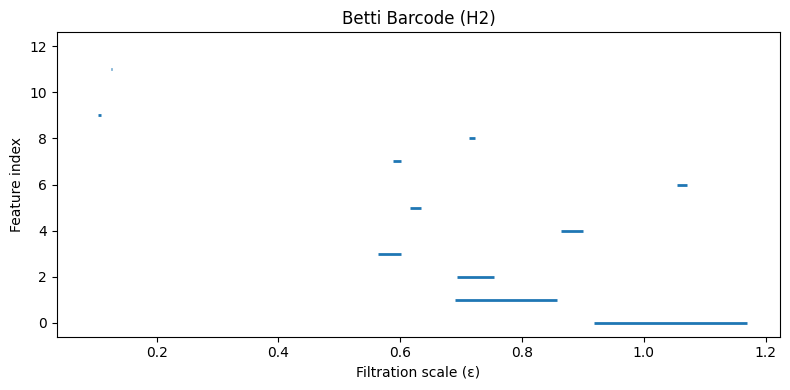

In [5]:
plot_betti_barcode(diagrams[0], homology_dim=0)
plot_betti_barcode(diagrams[0], homology_dim=1)
plot_betti_barcode(diagrams[0], homology_dim=2)

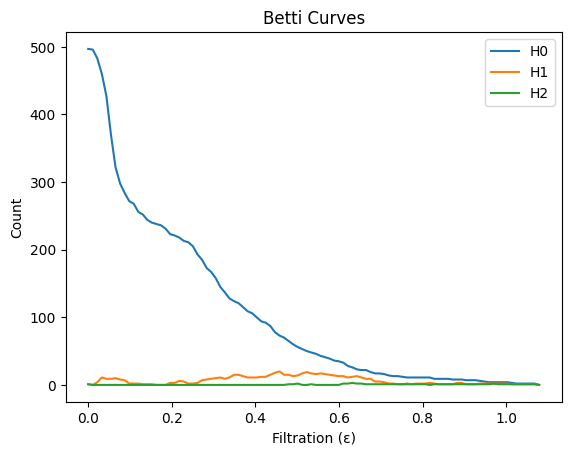

In [6]:
# Betti curves
bc = BettiCurve(n_bins=100)
betti_curves = bc.fit_transform(diagrams)
betti = betti_curves[0]  # (3, 100)
x = bc.samplings_[0]

plt.figure()
plt.title("Betti Curves")
plt.plot(x, betti[0], label="H0")
plt.plot(x, betti[1], label="H1")
plt.plot(x, betti[2], label="H2")
plt.legend()
plt.xlabel("Filtration (ε)")
plt.ylabel("Count")
plt.show()

In [7]:
from gtda.diagrams import Amplitude

amp = Amplitude(metric="wasserstein")
features = amp.fit_transform(diagrams)
print(features)

[[3.49990612 0.51844931 0.15676816]]


In [8]:
# trying sliding window
import numpy as np
from gtda.time_series import SlidingWindow
from gtda.homology import VietorisRipsPersistence
from gtda.diagrams import PairwiseDistance

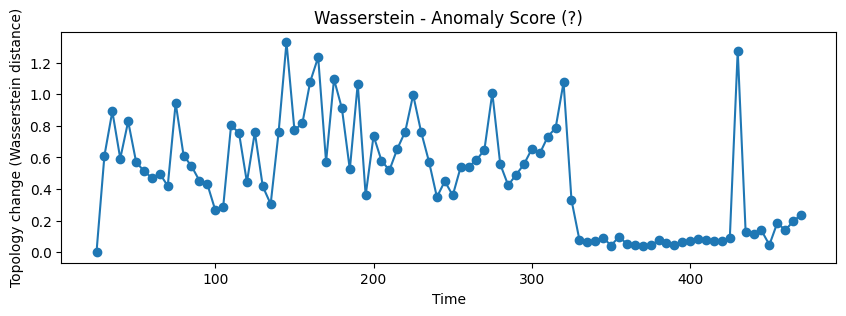

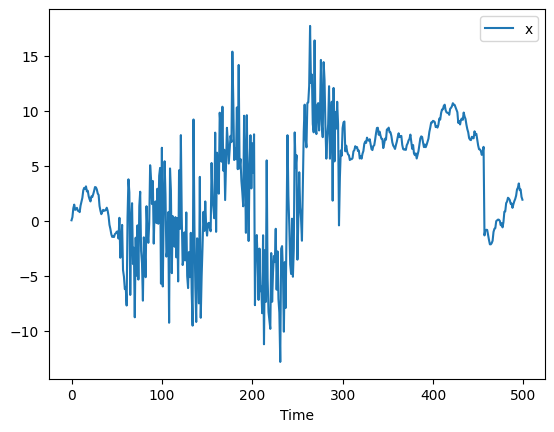

In [9]:
def make_windows(signal, window_size=50, stride=5):
    sw = SlidingWindow(size=window_size, stride=stride)
    X_windows = sw.fit_transform(signal)
    return X_windows
    
def compute_diagrams(X_windows, homology_dims=(0, 1)):
    VR = VietorisRipsPersistence(
        homology_dimensions=list(homology_dims),
        n_jobs=-1
    )
    diagrams = VR.fit_transform(X_windows)
    return diagrams
    
def wasserstein_anomaly_score(diagrams, order=1, internal_p=2):
    pw = PairwiseDistance(metric="wasserstein", order=order, n_jobs=-1)

    # compute full distance matrix
    D = pw.fit_transform(diagrams)

    # convert to time series: distance to previous window
    scores = np.zeros(len(diagrams))

    for t in range(1, len(diagrams)):
        scores[t] = D[t, t - 1]

    return scores

def tda_anomaly_pipeline(signal,
                         window_size=50,
                         stride=5,
                         homology_dims=(0, 1)):

    X_windows = make_windows(signal, window_size, stride)
    diagrams = compute_diagrams(X_windows, homology_dims)
    scores = wasserstein_anomaly_score(diagrams)

    return scores, X_windows, diagrams

def window_to_time_indices(n_windows, window_size, stride):
    return np.array([
        i * stride + window_size // 2
        for i in range(n_windows)
    ])

import matplotlib.pyplot as plt

def plot_anomaly_scores(scores, window_size, stride):
    t = window_to_time_indices(len(scores), window_size, stride)

    plt.figure(figsize=(10,3))
    plt.plot(t, scores, marker='o')
    plt.title("Wasserstein - Anomaly Score (?)")
    plt.xlabel("Time")
    plt.ylabel("Topology change (Wasserstein distance)")
    plt.show()

window_size = 50
stride = 5
homology_dims = (0, 1, 2)
scores, windows, diagrams = tda_anomaly_pipeline(point_cloud, window_size=window_size, stride=stride, homology_dims=homology_dims)
plot_anomaly_scores(scores, window_size=window_size, stride=stride)

# plot original for comparison
plt.figure()
plt.plot(df["t"], df["x"], label="x")
#plt.plot(df["t"], df["x2"], label="x2")
#plt.plot(df["t"], df["x3"], label="x3")
plt.xlabel("Time")
plt.legend()
plt.show()